# Temporal Fusion Transformer with Wavelet + PCA

This notebook extends the Wavelet-TFT pipeline by adding PCA on continuous features (including wavelet-derived ones) before training TFT.
It is designed as the third variant in your ablation study:
1) TFT (no wavelet, no PCA)
2) TFT + wavelet
3) TFT + wavelet + PCA

### Cell 1: Environment Setup
This cell prepares the runtime by checking/installing required libraries and importing everything used later (data prep, wavelets, PCA, TFT, and metrics).
It also sets random seeds so results are reproducible across runs.

In [3]:
# Install/import dependencies
import importlib.util
import subprocess
import sys

# Map import names to pip package names for runtime checks.
required_packages = {
    'lightning': 'lightning',
    'pytorch_forecasting': 'pytorch-forecasting',
    'pywt': 'PyWavelets',
    'sklearn': 'scikit-learn',
}

# Install only if missing, so reruns stay fast.
# If network is unavailable (common on restricted runtimes), we continue only when the module already exists.
for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])
        except Exception as e:
            if importlib.util.find_spec(module_name) is None:
                raise RuntimeError(
                    f"Could not install '{package_name}'. Network may be unavailable. "
                    f"On Kaggle, enable Internet or use a runtime where this package is preinstalled.\n"
                    f"Original error: {e}"
                )
            print(f"Warning: pip install failed for {package_name}, but module is available. Continuing.")

import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import torch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# Seed all major libraries for reproducible training behavior.
pl.seed_everything(42, workers=True)
np.random.seed(42)
torch.manual_seed(42)

print('Libraries ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.6 MB/s eta 0:00:00


Seed set to 42


Libraries ready.


### Cell 2: Data Loading and Initial Cleanup
This cell loads the dataset from local/Colab/Kaggle paths, parses timestamps, and applies the same baseline cleanup used in your other TFT notebooks.
It removes redundant phase channels, fills missing values meter-wise, and creates compact meter labels for grouped time-series training.

In [7]:
# Load data in the same style as the other TFT notebooks (Kaggle-first).
kaggle_default_path = '/kaggle/input/datasets/thebazkazam/total-consumption-data/total_consumption_data.csv'

if Path(kaggle_default_path).exists():
    data_path = kaggle_default_path
else:
    # Fallback: discover the file anywhere under /kaggle/input.
    data_path = None
    kaggle_input_root = Path('/kaggle/input')
    if kaggle_input_root.exists():
        matches = sorted(kaggle_input_root.rglob('total_consumption_data.csv'))
        if matches:
            data_path = str(matches[0])

    # Final fallbacks for Colab/local runs.
    if data_path is None:
        candidate_paths = [
            '/content/total_consumption_data.csv',
            'total_consumption_data.csv',
            '../total_consumption_data.csv',
            '../../total_consumption_data.csv',
        ]
        for p in candidate_paths:
            if Path(p).exists():
                data_path = p
                break

if data_path is None:
    raise FileNotFoundError(
        'Could not find total_consumption_data.csv. '
        'On Kaggle, attach the dataset and verify the input path.'
    )

df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

# Handle both UNIX-timestamp and already-formatted datetime columns.
if np.issubdtype(df['datetime'].dtype, np.number):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s', errors='coerce')
else:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Ensure all sensor columns are numeric before feature engineering.
for col in df.columns:
    if col not in ['datetime', 'meter_id']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['meter_id', 'datetime']).reset_index(drop=True)

# Meter-wise forward/backward fill keeps local temporal continuity.
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
df[num_cols] = df.groupby('meter_id')[num_cols].ffill()
df[num_cols] = df.groupby('meter_id')[num_cols].bfill()

# Remove redundant multi-phase channels and duplicate aggregates.
drop_cols = [
    'aenergy_ph2', 'aenergy_ph3', 'renergy_ph2', 'renergy_ph3',
    'apower_ph2', 'apower_ph3', 'rpower_ph2', 'rpower_ph3',
    'current_ph2', 'current_ph3', 'pfactor_ph2', 'pfactor_ph3',
    'voltage_ph2', 'voltage_ph3', 'apower', 'pfactor',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# Drop columns that carry no information (all zeros).
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
zero_cols = [c for c in num_cols if np.isclose(df[c].fillna(0).abs().sum(), 0)]
if zero_cols:
    df = df.drop(columns=zero_cols)

# Compact meter labels are useful as TFT static categorical IDs.
meter_ids = sorted(df['meter_id'].dropna().unique().tolist())
meter_map = {m: f'M{i:03d}' for i, m in enumerate(meter_ids)}
df['meter_label'] = df['meter_id'].map(meter_map).fillna('UNK')
df = df.dropna(subset=['datetime', 'meter_id']).copy()

print(f'Loaded data from: {data_path}')
print(f'Data shape: {df.shape}')
df.head()# Load data in the same style as the other TFT notebooks (Kaggle-first).
kaggle_default_path = '/kaggle/input/datasets/rahulsarav/total-consumption-data/total_consumption_data.csv'

if Path(kaggle_default_path).exists():
    data_path = kaggle_default_path
else:
    # Fallback: discover the file anywhere under /kaggle/input.
    data_path = None
    kaggle_input_root = Path('/kaggle/input')
    if kaggle_input_root.exists():
        matches = sorted(kaggle_input_root.rglob('total_consumption_data.csv'))
        if matches:
            data_path = str(matches[0])

    # Final fallbacks for Colab/local runs.
    if data_path is None:
        candidate_paths = [
            '/content/total_consumption_data.csv',
            'total_consumption_data.csv',
            '../total_consumption_data.csv',
            '../../total_consumption_data.csv',
        ]
        for p in candidate_paths:
            if Path(p).exists():
                data_path = p
                break

if data_path is None:
    raise FileNotFoundError(
        'Could not find total_consumption_data.csv. '
        'On Kaggle, attach the dataset and verify the input path.'
    )

df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

# Handle both UNIX-timestamp and already-formatted datetime columns.
if np.issubdtype(df['datetime'].dtype, np.number):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s', errors='coerce')
else:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Ensure all sensor columns are numeric before feature engineering.
for col in df.columns:
    if col not in ['datetime', 'meter_id']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['meter_id', 'datetime']).reset_index(drop=True)

# Meter-wise forward/backward fill keeps local temporal continuity.
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
df[num_cols] = df.groupby('meter_id')[num_cols].ffill()
df[num_cols] = df.groupby('meter_id')[num_cols].bfill()

# Remove redundant multi-phase channels and duplicate aggregates.
drop_cols = [
    'aenergy_ph2', 'aenergy_ph3', 'renergy_ph2', 'renergy_ph3',
    'apower_ph2', 'apower_ph3', 'rpower_ph2', 'rpower_ph3',
    'current_ph2', 'current_ph3', 'pfactor_ph2', 'pfactor_ph3',
    'voltage_ph2', 'voltage_ph3', 'apower', 'pfactor',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# Drop columns that carry no information (all zeros).
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
zero_cols = [c for c in num_cols if np.isclose(df[c].fillna(0).abs().sum(), 0)]
if zero_cols:
    df = df.drop(columns=zero_cols)

# Compact meter labels are useful as TFT static categorical IDs.
meter_ids = sorted(df['meter_id'].dropna().unique().tolist())
meter_map = {m: f'M{i:03d}' for i, m in enumerate(meter_ids)}
df['meter_label'] = df['meter_id'].map(meter_map).fillna('UNK')
df = df.dropna(subset=['datetime', 'meter_id']).copy()

print(f'Loaded data from: {data_path}')
print(f'Data shape: {df.shape}')
df.head()

Loaded data from: /kaggle/input/datasets/thebazkazam/total-consumption-data/total_consumption_data.csv
Data shape: (144256, 12)
Loaded data from: /kaggle/input/datasets/thebazkazam/total-consumption-data/total_consumption_data.csv
Data shape: (144256, 12)


,datetime,meter_id,aenergy,aenergy_ph1,renergy,renergy_ph1,apower_ph1,rpower_ph1,current_ph1,pfactor_ph1,voltage_ph1,meter_label
0,2019-08-27 22:00:05,00124B0018D6F607,4.0,19830.0,0.0,4765.0,242.0,-30.0,1.3,0.9,223.0,M000
1,2019-08-27 22:01:05,00124B0018D6F607,4.0,19834.0,0.0,4765.0,287.0,-32.0,1.4,0.9,223.0,M000
2,2019-08-27 22:02:05,00124B0018D6F607,11.0,19845.0,0.0,4765.0,1354.0,-34.0,6.1,1.0,221.0,M000
3,2019-08-27 22:03:05,00124B0018D6F607,22.0,19867.0,0.0,4765.0,1390.0,-36.0,6.2,1.0,223.0,M000
4,2019-08-27 22:04:05,00124B0018D6F607,24.0,19891.0,0.0,4765.0,1401.0,-36.0,6.3,1.0,222.0,M000


## Wavelet Feature Module

### Cell 3: Wavelet Utility Functions
This cell defines reusable helper functions for wavelet decomposition and feature extraction per meter.
For each selected signal, it generates multi-scale descriptors (approximation level, detail energy, and detail spread) that capture trend and high-frequency behavior.

In [8]:
def perform_wavelet_decomposition(signal, wavelet='db4', level=3, pad=True):
    # Convert to float and safely handle missing-only signals.
    signal = np.asarray(signal, dtype=np.float32)
    if np.isnan(signal).all():
        signal = np.zeros_like(signal)
    else:
        signal = np.nan_to_num(signal, nan=np.nanmean(signal))

    # Optional power-of-two padding helps stable wavelet decomposition.
    if pad:
        pad_len = 2 ** int(np.ceil(np.log2(max(1, len(signal)))))
        signal = np.pad(signal, (0, pad_len - len(signal)), mode='reflect')

    coeffs = pywt.wavedec(signal, wavelet, level=level)
    return {
        'cA': coeffs[0],
        'cD1': coeffs[1] if len(coeffs) > 1 else np.array([]),
        'cD2': coeffs[2] if len(coeffs) > 2 else np.array([]),
        'cD3': coeffs[3] if len(coeffs) > 3 else np.array([]),
    }

def extract_wavelet_features_per_meter(df_in, feature_cols, wavelet='db4', level=3):
    df_wv = df_in.copy()

    for col in feature_cols:
        if col not in df_wv.columns:
            continue

        # Pre-allocate vectors for faster per-meter assignment.
        wv_approx = np.zeros(len(df_wv), dtype=np.float32)
        wv_detail_energy = np.zeros(len(df_wv), dtype=np.float32)
        wv_detail_std = np.zeros(len(df_wv), dtype=np.float32)

        for meter_id in df_wv['meter_id'].unique():
            mask = df_wv['meter_id'] == meter_id
            idx = np.where(mask)[0]
            signal = df_wv.loc[mask, col].values.astype(np.float32)

            try:
                coeffs = perform_wavelet_decomposition(signal, wavelet=wavelet, level=level)
                cA = coeffs['cA']
                # Interpolate approximation coefficients back to original signal length.
                cA_upsampled = np.interp(
                    np.arange(len(signal)),
                    np.linspace(0, len(signal) - 1, len(cA)),
                    cA
                )

                details = [coeffs[k] for k in ['cD1', 'cD2', 'cD3'] if len(coeffs[k]) > 0]
                d_concat = np.concatenate(details) if details else np.array([0.0], dtype=np.float32)

                wv_approx[idx] = np.abs(cA_upsampled)
                wv_detail_energy[idx] = np.sum(d_concat ** 2) / max(1, len(signal))
                wv_detail_std[idx] = np.std(d_concat)
            except Exception:
                # Keep defaults if decomposition fails for edge cases.
                pass

        # Add 3 wavelet descriptors per source feature.
        df_wv[f'{col}_wv_approx'] = wv_approx
        df_wv[f'{col}_wv_detail_energy'] = wv_detail_energy
        df_wv[f'{col}_wv_detail_std'] = wv_detail_std

    return df_wv

print('Wavelet functions ready.')

Wavelet functions ready.


## Feature Engineering: Base + Wavelet + PCA

### Cell 4: Base Features + Wavelet Features + PCA
This is the core feature-engineering stage: it builds baseline temporal/power features, adds wavelet-derived features, then applies PCA on continuous features.
Important: PCA is fit only on the training partition to prevent leakage, and the transformed components are appended to the final TFT feature set.

In [9]:
df_fe = df.copy()

# Base engineered features
df_fe['apparent_power_ph1'] = df_fe['voltage_ph1'] * df_fe['current_ph1']
df_fe['pf_angle_ph1'] = np.arccos(np.clip(df_fe['pfactor_ph1'], -1, 1))
df_fe['energy_intensity'] = df_fe['aenergy_ph1'] / (df_fe['apparent_power_ph1'].abs() + 1e-6)
df_fe['Q_P_ratio'] = df_fe['rpower_ph1'] / (df_fe['apower_ph1'].abs() + 1e-6)
df_fe['hour'] = df_fe['datetime'].dt.hour.astype('int16')
df_fe['dayofweek'] = df_fe['datetime'].dt.dayofweek.astype('int16')
df_fe['is_weekend'] = (df_fe['dayofweek'] >= 5).astype('int8')
df_fe['is_peak'] = df_fe['hour'].between(8, 20).astype('int8')
df_fe['apower_roll3'] = (
    df_fe.groupby('meter_id')['apower_ph1']
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Signals selected for wavelet decomposition (multi-scale descriptors).
wavelet_src_cols = ['apower_ph1', 'rpower_ph1', 'voltage_ph1', 'aenergy_ph1']
df_fe = extract_wavelet_features_per_meter(df_fe, wavelet_src_cols, wavelet='db4', level=3)

base_feature_cols = [
    'aenergy', 'aenergy_ph1', 'renergy', 'renergy_ph1',
    'apower_ph1', 'rpower_ph1', 'current_ph1', 'pfactor_ph1', 'voltage_ph1',
    'apparent_power_ph1', 'pf_angle_ph1', 'energy_intensity', 'Q_P_ratio',
    'hour', 'dayofweek', 'is_weekend', 'is_peak', 'apower_roll3',
]

wavelet_feature_cols = [
    f'{c}_wv_approx' for c in wavelet_src_cols
] + [
    f'{c}_wv_detail_energy' for c in wavelet_src_cols
] + [
    f'{c}_wv_detail_std' for c in wavelet_src_cols
]

base_feature_cols = [c for c in base_feature_cols if c in df_fe.columns]
wavelet_feature_cols = [c for c in wavelet_feature_cols if c in df_fe.columns]

target_col = 'apower_ph1'

# Clean infinities/missing values before scaling and PCA.
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
numeric_fill_cols = list(set(base_feature_cols + wavelet_feature_cols + [target_col]))
for c in numeric_fill_cols:
    df_fe[c] = pd.to_numeric(df_fe[c], errors='coerce')
df_fe[numeric_fill_cols] = df_fe[numeric_fill_cols].fillna(df_fe[numeric_fill_cols].median(numeric_only=True))

# Chronological index and splits (used to avoid leakage for PCA fitting)
df_fe = df_fe.sort_values(['meter_id', 'datetime']).reset_index(drop=True)
df_fe['time_idx'] = df_fe.groupby('meter_id').cumcount()
group_max_idx = df_fe.groupby('meter_id')['time_idx'].max()
train_cutoffs = (group_max_idx * 0.70).astype(int)
val_cutoffs = (group_max_idx * 0.85).astype(int)
df_fe['train_cutoff'] = df_fe['meter_id'].map(train_cutoffs)
df_fe['val_cutoff'] = df_fe['meter_id'].map(val_cutoffs)

# PCA on continuous features fit ONLY on train partition
cont_for_pca = [c for c in (base_feature_cols + wavelet_feature_cols) if c not in ['hour', 'dayofweek', 'is_weekend', 'is_peak']]
train_mask = df_fe['time_idx'] <= df_fe['train_cutoff']

# Standardize before PCA, fit on train only, then transform all rows.
scaler = StandardScaler()
X_train = scaler.fit_transform(df_fe.loc[train_mask, cont_for_pca])
X_all = scaler.transform(df_fe[cont_for_pca])

# Keep a compact component count for stability and easy comparison.
pca_n_components = min(12, len(cont_for_pca))
pca = PCA(n_components=pca_n_components, random_state=42)
pca.fit(X_train)
X_pca_all = pca.transform(X_all)

pca_cols = [f'pca_{i+1}' for i in range(pca_n_components)]
for i, c in enumerate(pca_cols):
    df_fe[c] = X_pca_all[:, i]

feature_cols = base_feature_cols + wavelet_feature_cols + pca_cols

# Filter short meter sequences that cannot support encoder+prediction windows.
max_encoder_length = 24
max_prediction_length = 1
min_len = max_encoder_length + max_prediction_length + 1
valid_meters = df_fe.groupby('meter_id').size()
valid_meters = valid_meters[valid_meters >= min_len].index
df_fe = df_fe[df_fe['meter_id'].isin(valid_meters)].copy()

print(f'Total features used: {len(feature_cols)}')
print(f'PCA components: {len(pca_cols)} | Explained variance: {pca.explained_variance_ratio_.sum():.4f}')
df_fe[feature_cols + [target_col]].head()

Total features used: 42
PCA components: 12 | Explained variance: 0.9759


,aenergy,aenergy_ph1,renergy,renergy_ph1,apower_ph1,rpower_ph1,current_ph1,pfactor_ph1,voltage_ph1,apparent_power_ph1,...,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,apower_ph1
0,4.0,19830.0,0.0,4765.0,242.0,-30.0,1.3,0.9,223.0,289.9,...,-1.308956,0.698694,0.839977,-0.486620,0.609931,-0.844296,-0.235096,-0.242865,-0.858885,242.0
1,4.0,19834.0,0.0,4765.0,287.0,-32.0,1.4,0.9,223.0,312.2,...,-1.311656,0.708500,0.862590,-0.457026,0.644971,-0.834274,-0.247089,-0.233979,-0.855219,287.0
2,11.0,19845.0,0.0,4765.0,1354.0,-34.0,6.1,1.0,221.0,1348.1,...,-1.504835,0.612565,0.768008,-0.035758,0.698782,-0.321818,-0.549312,0.079071,-1.292849,1354.0
3,22.0,19867.0,0.0,4765.0,1390.0,-36.0,6.2,1.0,223.0,1382.6,...,-1.552460,0.556252,0.791249,0.085260,0.767582,-0.423168,-0.100336,-0.274069,-0.843497,1390.0
4,24.0,19891.0,0.0,4765.0,1401.0,-36.0,6.3,1.0,222.0,1398.6,...,-1.592042,0.580317,0.767374,0.118808,0.873233,-0.541530,-0.003429,-0.363552,-0.666408,1401.0


## TimeSeriesDataSet and TFT Training

### Cell 5: TFT Dataset Construction and Model Training
This cell builds chronological train/validation/test TimeSeriesDataSet objects, defines known vs unknown real-valued variables, and creates dataloaders.
It then configures TFT hyperparameters, trains with early stopping, and loads the best checkpoint for evaluation.

In [10]:
# Chronological split views (train <=70%, val <=85%, full test).
train_df = df_fe[df_fe['time_idx'] <= df_fe['train_cutoff']].copy()
val_df = df_fe[df_fe['time_idx'] <= df_fe['val_cutoff']].copy()
test_df = df_fe.copy()

# Known reals are calendar/index signals known ahead of prediction time.
known_reals = ['time_idx', 'hour', 'dayofweek', 'is_weekend', 'is_peak']
unknown_reals = [c for c in feature_cols if c not in known_reals]
if target_col not in unknown_reals:
    unknown_reals = [target_col] + unknown_reals

# Build TFT dataset with per-meter normalization and sequence features.
training = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=target_col,
    group_ids=['meter_id'],
    static_categoricals=['meter_label'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    target_normalizer=GroupNormalizer(groups=['meter_id']),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, val_df, stop_randomization=True)
testing = TimeSeriesDataSet.from_dataset(training, test_df, stop_randomization=True)

# Dataloaders for training and deterministic evaluation.
train_loader = training.to_dataloader(train=True, batch_size=128, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=256, num_workers=0)
test_loader = testing.to_dataloader(train=False, batch_size=256, num_workers=0)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=5, mode='min')

trainer = pl.Trainer(
    max_epochs=15,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop],
    logger=False,
    enable_checkpointing=True,
    enable_model_summary=True,
)

# Keep TFT hyperparameters aligned with your other variants for fair comparison.
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=3,
)

print(f'Trainable parameters: {tft.size() / 1e3:.1f}k')
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

# Reload best checkpoint selected by validation loss.
best_ckpt = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
best_ckpt

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Trainable parameters: 178.6k


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     24 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.5 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.9 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  108 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 11.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 955                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=15` reached.


'/kaggle/working/checkpoints/epoch=14-step=11820.ckpt'

## Evaluation and Artifacts

### Cell 6: Metrics, Predictions, and Saved Artifacts
This cell runs inference on validation and test splits, computes regression metrics (MAE, RMSE, R2, MAPE), and prints the final performance table.
It also saves model and run artifacts (checkpoint + metrics CSV + run-info CSV) so this variant can be compared directly with your other TFT runs.

In [11]:
def flatten_targets(raw_target):
    # PyTorch Forecasting can return tuple/list targets; normalize to flat numpy.
    if isinstance(raw_target, (list, tuple)):
        arr = raw_target[0]
    else:
        arr = raw_target
    if hasattr(arr, 'detach'):
        arr = arr.detach().cpu().numpy()
    return np.asarray(arr).reshape(-1)

def collect_true_pred(model, loader):
    # Predict all batches and align with flattened ground truth.
    preds = model.predict(loader).detach().cpu().numpy().reshape(-1)
    trues = []
    for _, y in loader:
        trues.append(flatten_targets(y))
    trues = np.concatenate(trues, axis=0)[:len(preds)]
    return trues, preds

def regression_metrics(y_true, y_pred):
    # Standard regression metrics used in notebook comparisons.
    eps = 1e-6
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE(%)': mape}

val_true, val_pred = collect_true_pred(best_tft, val_loader)
test_true, test_pred = collect_true_pred(best_tft, test_loader)

metrics_df = pd.DataFrame([
    regression_metrics(val_true, val_pred),
    regression_metrics(test_true, test_pred),
], index=['Validation', 'Test'])

print('METRICS: TFT + WAVELET + PCA')
print(metrics_df.round(4))

# Save artifacts
import shutil
shutil.copy(best_ckpt, 'tft_wavelet_pca.ckpt')
metrics_df.to_csv('tft_wavelet_pca_metrics.csv', index=True)

# Save lightweight metadata for reproducibility and reporting.
run_info = pd.DataFrame({
    'Metric': ['Train Samples', 'Val Samples', 'Test Samples', 'Feature Count', 'Wavelet Type', 'Wavelet Level', 'PCA Components'],
    'Value': [len(train_df), len(val_df), len(test_df), len(feature_cols), 'db4', 3, len(pca_cols)],
})
run_info.to_csv('tft_wavelet_pca_run_info.csv', index=False)

print('Saved:')
print('- tft_wavelet_pca.ckpt')
print('- tft_wavelet_pca_metrics.csv')
print('- tft_wavelet_pca_run_info.csv')

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2026-04-17 20:38:13.556733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been regist

METRICS: TFT + WAVELET + PCA
                MAE      RMSE      R2  MAPE(%)
Validation  81.7288  261.6775  0.8706  23.6673
Test        78.5696  257.0220  0.8674  23.5762
Saved:
- tft_wavelet_pca.ckpt
- tft_wavelet_pca_metrics.csv
- tft_wavelet_pca_run_info.csv


### Cell 6b: Metric Visualizations
This cell turns the validation and test metrics into plots so you can compare the PCA variant visually.
It also shows actual-vs-predicted scatter plots and residual histograms for a quick fit check.


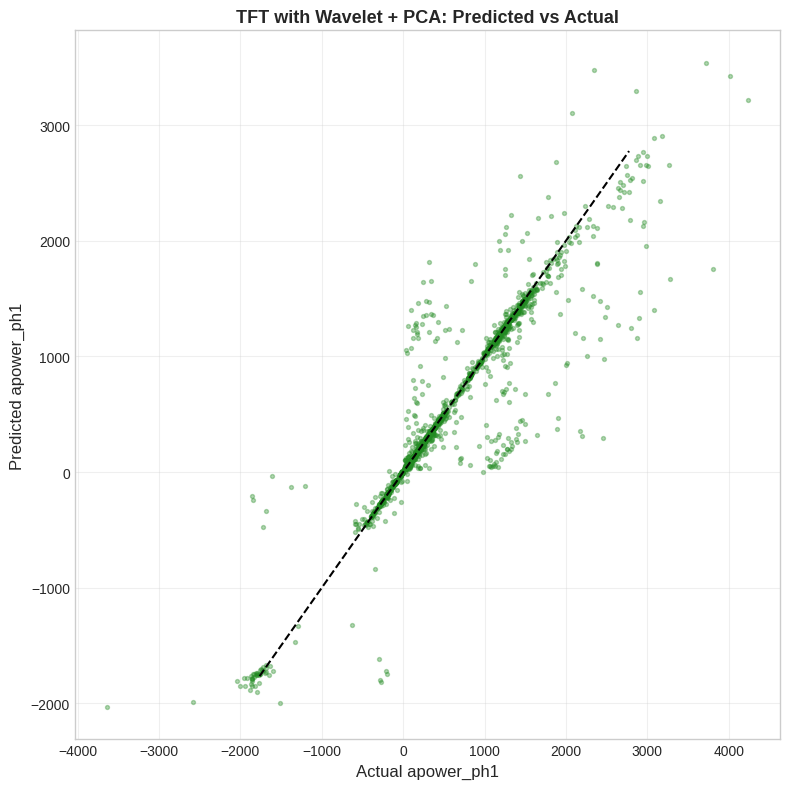

In [14]:
# Scatter plot: predicted vs actual
sample_n = min(3000, len(test_true))
idx = np.random.choice(len(test_true), size=sample_n, replace=False)

plt.figure(figsize=(8, 8))
plt.scatter(test_true[idx], test_pred[idx], s=8, alpha=0.35, color='forestgreen')
diag_min, diag_max = np.percentile(test_true, [1, 99])
plt.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', lw=1.5)
plt.xlabel('Actual apower_ph1', fontsize=12)
plt.ylabel('Predicted apower_ph1', fontsize=12)
plt.title('TFT with Wavelet + PCA: Predicted vs Actual', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


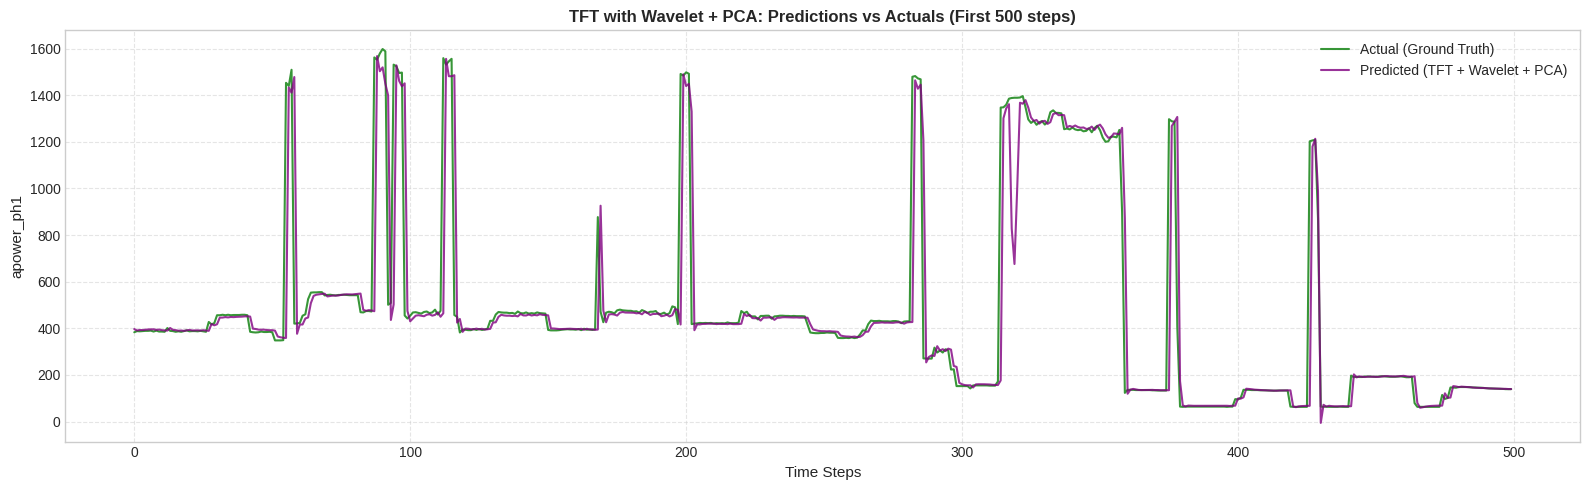

In [15]:
# Time series plot: predictions vs actuals
time_frame = 500

plt.figure(figsize=(16, 5))
plt.plot(test_true[:time_frame], label='Actual (Ground Truth)', color='forestgreen', alpha=0.9, lw=1.5)
plt.plot(test_pred[:time_frame], label='Predicted (TFT + Wavelet + PCA)', color='purple', alpha=0.8, lw=1.5)
plt.xlabel('Time Steps', fontsize=11)
plt.ylabel('apower_ph1', fontsize=11)
plt.title(f'TFT with Wavelet + PCA: Predictions vs Actuals (First {time_frame} steps)', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Generating model interpretation...


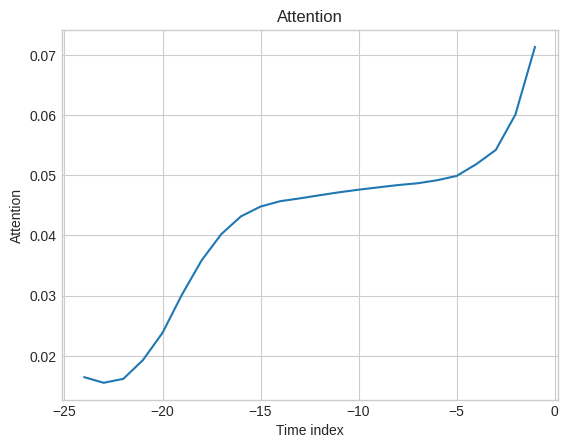

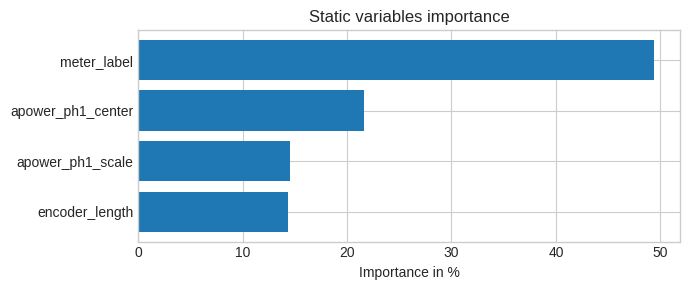

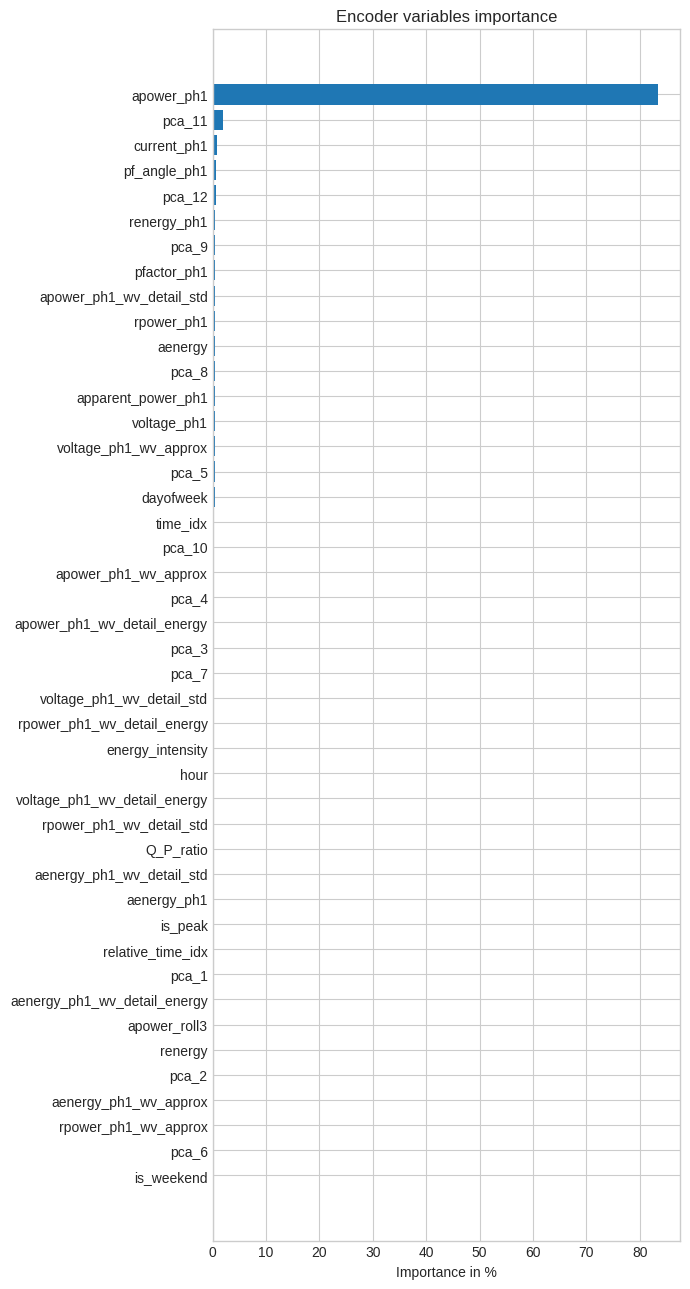

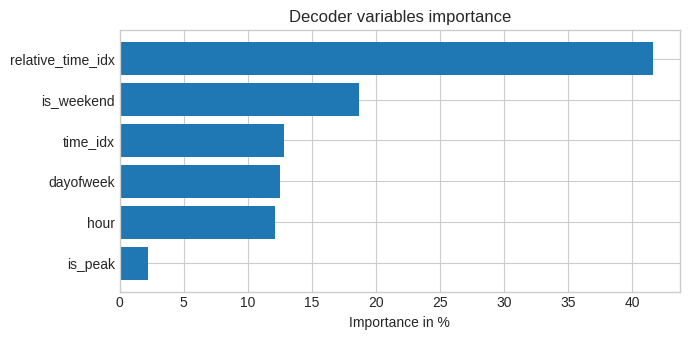

In [16]:
# Feature importance and model interpretation
print('Generating model interpretation...')
try:
    predict_output = best_tft.predict(
        val_loader,
        mode='raw',
        return_x=True,
        trainer_kwargs=dict(accelerator='gpu' if torch.cuda.is_available() else 'cpu')
    )
    raw_preds, x = predict_output[0], predict_output[1]
    interpretation = best_tft.interpret_output(raw_preds, reduction='sum')
    best_tft.plot_interpretation(interpretation)
except Exception as e:
    print(f'Interpretation plot skipped: {e}')


## 8. Save Artifacts & Model

In [18]:
import shutil

# Save checkpoint
shutil.copy(best_ckpt, 'tft_wavelet_pca.ckpt')

# Save metrics
metrics_df.to_csv('tft_wavelet_pca_metrics.csv', index=True)

# Save detailed results
results_summary = pd.DataFrame({
    'Metric': ['Train Samples', 'Val Samples', 'Test Samples', 'Feature Count', 'Wavelet Type', 'Decomposition Level', 'PCA Components'],
    'Value': [len(train_df), len(val_df), len(test_df), len(feature_cols), 'db4', '3', len(pca_cols)]
})
results_summary.to_csv('tft_wavelet_pca_run_info.csv', index=False)

print('\n' + '='*60)
print('ARTIFACTS SAVED')
print('='*60)
print('✓ tft_wavelet_pca.ckpt')
print('✓ tft_wavelet_pca_metrics.csv')
print('✓ tft_wavelet_pca_run_info.csv')
print('='*60)



ARTIFACTS SAVED
✓ tft_wavelet_pca.ckpt
✓ tft_wavelet_pca_metrics.csv
✓ tft_wavelet_pca_run_info.csv
